In [1]:
import scanpy as sc
import os
import re

data_folder = "./"
adata_all = None  # This will hold the concatenated result

for filename in sorted(os.listdir(data_folder)):  # sorted for reproducibility
    if filename.endswith(".h5"):
        filepath = os.path.join(data_folder, filename)

        # Read the 10X file
        adata = sc.read_10x_h5(filepath)

        # Make gene names unique to avoid issues
        adata.var_names_make_unique()

        # Extract batch name from filename
        match = re.search(r'rep\d+', filename)
        batch = match.group(0) if match else "unknown"

        # Add batch manually (Scanpy will also add its own if using concatenate)
        adata.obs['batch'] = batch

        # Prefix obs_names to ensure uniqueness
        adata.obs_names = [f"{batch}_{x}" for x in adata.obs_names]

        if adata_all is None:
            adata_all = adata
        else:
            adata_all = adata_all.concatenate(adata, batch_key='batch', batch_categories=[adata_all.obs['batch'][0], batch])

In [4]:
adata_all.obs_names = adata_all.obs_names.str.extract(r'_(.+?-\d+)-')[0]

In [5]:
adata_all.obs_names


Index(['AAACAGCCAATATAGG-1', 'AAACAGCCACAGCCAT-1', 'AAACAGCCATAATGAG-1',
       'AAACAGCCATAGCTTG-1', 'AAACATGCAACTGGGA-1', 'AAACATGCAAGTCGCT-1',
       'AAACATGCACCTGTAA-1', 'AAACATGCAGCTTAGC-1', 'AAACATGCAGGCTTCG-1',
       'AAACATGCATAATGAG-1',
       ...
       'TTTGTGTTCTGTGAGT-1', 'TTTGTTGGTAGGTTAT-1', 'TTTGTTGGTATTACCC-1',
       'TTTGTTGGTCAGGCAT-1', 'TTTGTTGGTCATCATC-1', 'TTTGTTGGTCCTAGTT-1',
       'TTTGTTGGTGTCACGG-1', 'TTTGTTGGTGTGTGGT-1', 'TTTGTTGGTTCTTTAG-1',
       'TTTGTTGGTTGTGATG-1'],
      dtype='object', length=144439)

In [6]:
import pandas as pd
metadata = pd.read_csv('./GSE274113_annotated_metadata.csv')

In [7]:
metadata["Unnamed: 0"] = metadata["Unnamed: 0"].str.extract(r'_(.+)')


In [9]:
metadata.set_index('Unnamed: 0', inplace=True)


In [11]:
# Step 1: Ensure unique indices
adata_all = adata_all[~adata_all.obs_names.duplicated(), :]

# Remove duplicates from metadata as well
metadata_unique = metadata.loc[~metadata.index.duplicated()]

# Subset adata to common cells
common_cells = adata_all.obs_names.intersection(metadata_unique.index)
adata_subset = adata_all[common_cells, :]

# Step 2: Map metadata columns to adata.obs
for column in metadata_unique.columns:
    adata_subset.obs[column] = metadata_unique.loc[adata_subset.obs_names, column].values

/tmp/ipykernel_2036241/984044570.py:13: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_subset.obs[column] = metadata_unique.loc[adata_subset.obs_names, column].values


In [12]:
adata_subset

AnnData object with n_obs × n_vars = 118269 × 36601
    obs: 'batch', 'perturbation', 'replicate', 'Timepoint', 'nCount_RNA', 'nFeature_RNA', 'nCount_atac', 'nFeature_atac', 'perturbation_name', 'target', 'new_CellType', 'annotation_simplified'
    var: 'gene_ids', 'feature_types', 'genome', 'interval'

In [13]:
adata_subset.obs['new_CellType'].value_counts()


new_CellType
Pro-Erythroblast               37225
Polychromatic Erythroblast     19748
Basophilic Erythroblast        18787
EoBasoMast Precursor           12573
Orthochromatic Erythroblast    11619
CFU-E                           9713
BFU-E                           2476
Megakaryocyte Precursor          877
MEP                              595
Early GMP                        243
CD14 Mono                         87
Cycling Progenitor                83
Stromal                           68
LMPP                              59
cDC2                              50
Pre-cDC                           35
Pre-pDC                           26
MPP-MkEry                         22
GMP-Mono                          20
HSC                               15
Early ProMono                     13
MPP-MyLy                          13
GMP-Neut                           8
MLP                                7
Megakaryocyte                      6
CLP                                6
GMP-Cycle                

In [14]:
# Step 1: Get the cell types with fewer than 100 cells
cell_type_counts = adata_subset.obs['new_CellType'].value_counts()
cell_types_to_remove = cell_type_counts[cell_type_counts < 100].index

# Step 2: Filter out the cells that belong to the cell types with fewer than 100 cells
adata_subset_filtered = adata_subset[~adata_subset.obs['new_CellType'].isin(cell_types_to_remove), :]

In [15]:
adata_subset_filtered.X.max()


np.float32(41767.0)

In [16]:
adata_subset_filtered.layers['counts']=adata_subset_filtered.X.copy()


/tmp/ipykernel_2036241/3653277259.py:1: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata_subset_filtered.layers['counts']=adata_subset_filtered.X.copy()


In [17]:
adata_subset_filtered.var['mt'] = adata_subset_filtered.var_names.str.upper().str.startswith('MT-')
sc.pp.calculate_qc_metrics(
    adata_subset_filtered,
    qc_vars=['mt'],
    inplace=True
)

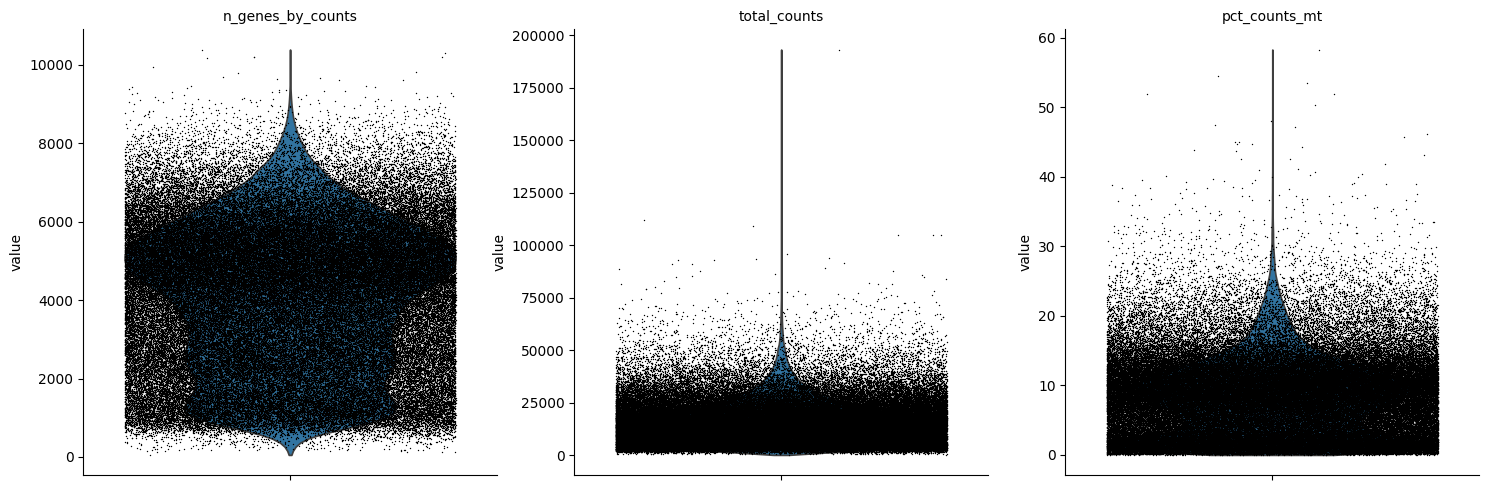

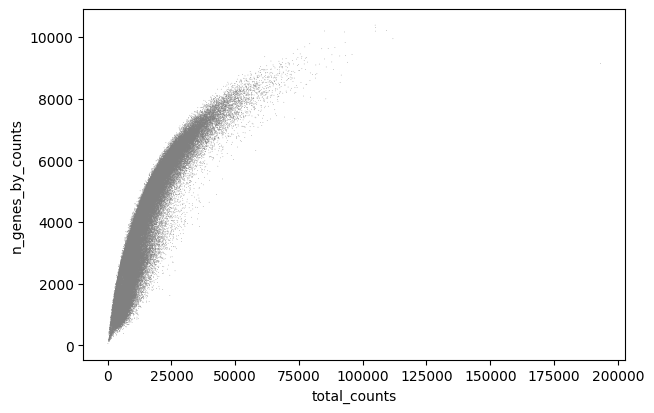

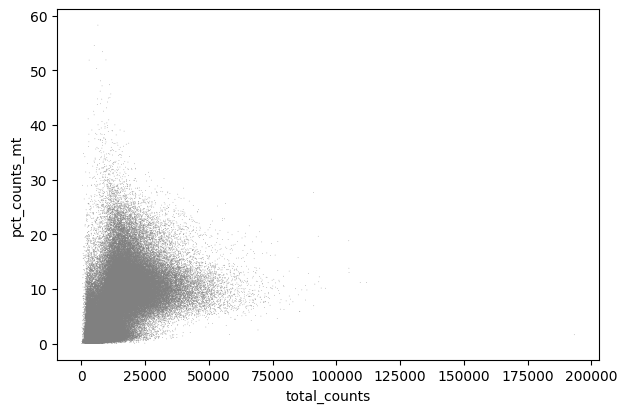

In [18]:
# Violin plots
sc.pl.violin(adata_subset_filtered, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True)

# Scatter plots
sc.pl.scatter(adata_subset_filtered, x='total_counts', y='n_genes_by_counts')
sc.pl.scatter(adata_subset_filtered, x='total_counts', y='pct_counts_mt')

In [19]:
max_mt_pct = 20
adata_subset_filtered = adata_subset_filtered[(adata_subset_filtered.obs['pct_counts_mt'] < max_mt_pct),:]    

In [20]:
sc.pp.filter_genes(adata_subset_filtered,min_counts=1000)
sc.pp.filter_genes(adata_subset_filtered, min_cells=10)

/software/cellgen/team361/am74/envs/scanpy/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:281: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_counts"] = number


In [21]:
sc.pp.filter_cells(adata_subset_filtered,min_counts=1000)
sc.pp.filter_cells(adata_subset_filtered,max_counts=50000)
sc.pp.filter_cells(adata_subset_filtered,min_genes=2000)

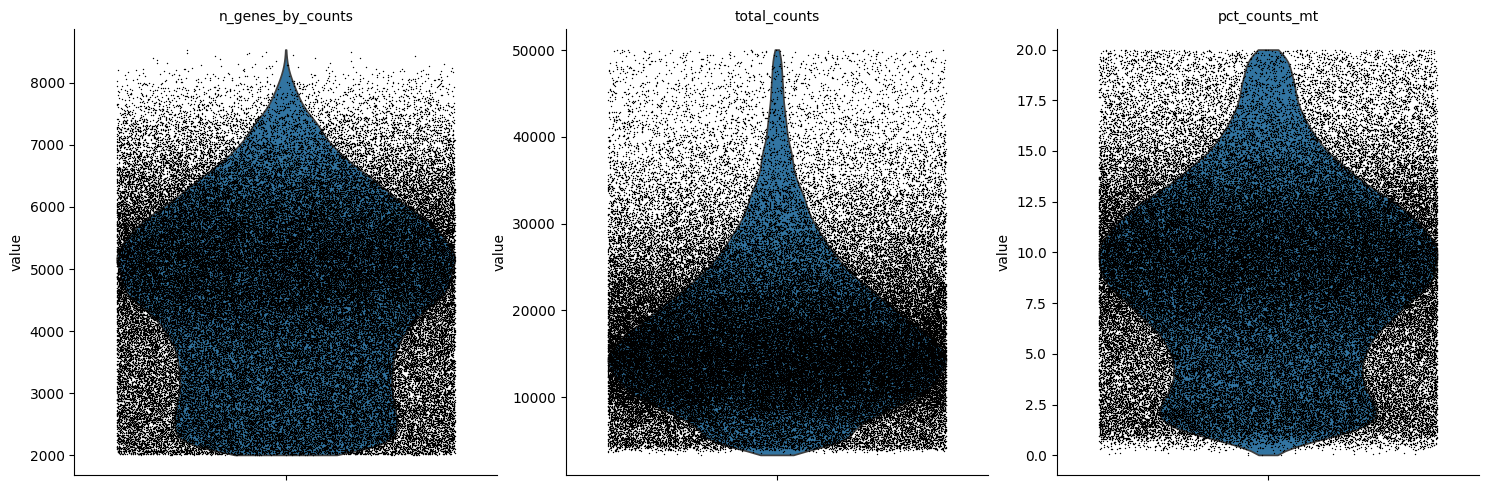

In [22]:
sc.pl.violin(adata_subset_filtered, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True)


In [23]:
adata_subset_filtered


AnnData object with n_obs × n_vars = 92286 × 15662
    obs: 'batch', 'perturbation', 'replicate', 'Timepoint', 'nCount_RNA', 'nFeature_RNA', 'nCount_atac', 'nFeature_atac', 'perturbation_name', 'target', 'new_CellType', 'annotation_simplified', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells'
    layers: 'counts'

In [24]:
sc.pp.normalize_total(adata_subset_filtered)
sc.pp.log1p(adata_subset_filtered)

In [25]:
adata_subset_filtered.write_h5ad('./processed_data.h5ad')